# TECH CHALLENGE FASE 1

**Case NPS Preditivo**

**Integrantes:** Felipe Cavalcanti, Gleison, Gustavo Soares, Marcus Magalhães e Pietro Costa.

## **1. Entendimento do Negócio**


### **Qual problema de negócio está sendo resolvido?**

O e-commerce enfrenta um ciclo de **insatisfação silenciosa**: clientes vivenciam problemas operacionais (atrasos, reclamações, múltiplos contatos com SAC), mas a empresa só descobre essa insatisfação *após* a pesquisa de NPS — quando o dano já está feito.

O problema central é a **ausência de capacidade preditiva**. Sem saber quais clientes estão em risco de se tornarem detratores, a empresa não consegue agir preventivamente. A solução é transformar dados operacionais já disponíveis em um **modelo preditivo de NPS**, identificando clientes em risco durante a jornada, antes da pesquisa.

### **Por que o NPS é importante para um e-commerce?**

O NPS é a métrica direta de lealdade e intenção de recomendação. No e-commerce, importa por três razões:

**1. Recompra e Receita Recorrente:** Promotores (NPS ≥ 9) recompram com maior frequência. Os dados confirmam: clientes com recompra em 30 dias têm NPS médio de 9,0, contra 3,9 dos que não recompram.

**2. Boca a Boca e CAC:** Promotores geram tráfego orgânico. Detratores publicam avaliações negativas (Reclame Aqui, redes sociais), aumentando o custo de aquisição.

**3. Market Share:** Com NPS de -69,6, a empresa está em posição de perda de participação. Empresas com NPS alto crescem até 2x mais rápido que concorrentes com NPS baixo.

### **Quais áreas poderiam se beneficiar desses insights?**

**Logística:** Maior alavancagem. Atraso na entrega tem correlação de -0,60 com o NPS. Pode redefinir SLAs e acionar parceiros preventivamente.

**SAC:** Com o modelo preditivo, pode adotar postura proativa — contato antes da abertura do chamado, reduzindo volume de reclamações.

**Produto e Tecnologia:** Melhorias em rastreamento em tempo real, comunicação de prazo e histórico centralizado de atendimento.

**Pricing e Comercial:** Avaliar impacto do frete e ticket médio para orientar campanhas e políticas de desconto.

**Estratégia:** Dashboards executivos com indicadores antecedentes de satisfação, substituindo análise reativa por monitoramento em tempo real.

### **Reflexão: Como o NPS impacta Recompra, Boca a Boca e Market Share**

**Recompra:** Há relação direta entre NPS e recompra. Detratores raramente voltam — em e-commerce, a fricção para migrar a um concorrente é quase zero. Os dados confirmam: clientes com recompra têm NPS médio próximo de 9.

**Boca a Boca:** Uma avaliação negativa no Reclame Aqui pode ser lida por centenas de potenciais clientes antes de uma compra. O promotor indica organicamente — gerando conversões de alto valor sem custo de mídia.

**Market Share:** O NPS funciona como indicador antecedente de market share. Um e-commerce com NPS de -69,6 está, na prática, financiando a aquisição de clientes pelos concorrentes.

### **Indicadores de mercado que complementariam a análise**

- **Benchmark NPS no e-commerce brasileiro:** empresas de referência operam entre +20 e +60. O -60,0 indica distância crítica do padrão.
- **SLA logístico do setor:** tempo médio de entrega por região e transportadora.
- **Taxa de Reclame Aqui:** índice de resolução e tempo de resposta — correlacionável com `resolution_time_days`.
- **Churn Rate:** taxa de abandono da base cruzada com perfil de NPS.
- **Customer Lifetime Value (CLV):** valor total de um promotor vs. detrator ao longo da jornada.
- **CES (Customer Effort Score):** mede esforço do cliente para resolver problemas — complementar ao NPS em operações de atendimento.

## **2. Definição da Target**



### **Qual variável representa a satisfação do cliente?**

A variável `nps_score` representa diretamente a satisfação e lealdade do cliente — escala de 0 a 10, coletada após a conclusão da jornada de compra.

### **Por que ela foi escolhida?**

O `nps_score` foi escolhido como variável alvo por quatro razões:

1. É a **métrica oficial de lealdade**, usada globalmente como padrão de experiência do consumidor.
2. É coletada ao **final da jornada**, capturando a percepção consolidada de todas as interações.
3. Tem **alta correlação com comportamentos de negócio**: clientes com notas altas recompram mais; com notas baixas, reclamam mais.
4. Permite **classificação acionável**: Promotores, Neutros e Detratores traduzem diretamente em prioridades operacionais.

### **Em que momento da jornada essa informação é coletada?**

O NPS é coletado **após o encerramento completo da jornada** — após entrega e resolução de chamados. Quando a empresa recebe a nota, a jornada já terminou e não há mais oportunidade de intervenção.

É por isso que o modelo preditivo faz sentido: usa dados operacionais gerados *durante* a jornada para antecipar o NPS *depois* dela.

### **Existe algum risco de usar essa variável de forma inadequada?**

Sim. Os principais riscos são:

**1. Viés de não-resposta:** Clientes extremamente insatisfeitos podem não responder, distorcendo o conjunto de treinamento.

**2. Data Leakage:** `csat_internal_score` pode ter sido coletado no mesmo momento que o NPS. Usá-la como feature inflaria o desempenho artificialmente — por isso foi excluída.

**3. Correlação ≠ Causalidade:** O modelo indica associações, não causas. Agir apenas no sintoma sem tratar a causa raiz limita o impacto.

**4. Desatualização:** O comportamento do consumidor muda com o tempo. O modelo precisa ser monitorado e re-treinado periodicamente.

**5. Uso punitivo:** O score preditivo deve ser usado preventivamente, não para reduzir investimento em clientes classificados como prováveis detratores.

## **3. Análise Exploratória dos Dados (EDA)**

### **3.1 Importações e Carregamento dos Dados**

In [18]:
# ── Bibliotecas principais ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Modelagem ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.pipeline import Pipeline
import joblib

# ── Configurações visuais ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
COLORS = {'promotor': '#2ecc71', 'neutro': '#f39c12', 'detrator': '#e74c3c', 'accent': '#2980b9'}

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [19]:
# ── Carregamento ─────────────────────────────────────────────────────────────
df = pd.read_csv('desafio_nps_fase_1.csv')

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head()

Shape: (2500, 19)
Colunas: ['customer_id', 'customer_age', 'customer_region', 'customer_tenure_months', 'order_id', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'nps_score', 'repeat_purchase_30d', 'complaints_count', 'csat_internal_score']


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### **3.2 Entendimento e Qualidade dos Dados**

In [20]:
# ── Tipos ─────────────────────────────────────────────────────
print('=== Tipos de dados ===')
print(df.dtypes)
print()

=== Tipos de dados ===
customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object



In [21]:
# ── valores nulos ────────────────────────────────────────────────
print('=== Valores nulos ===')
print(df.isnull().sum())

=== Valores nulos ===
customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64


In [22]:
# ── Estatísticas descritivas ──────────────────────────────────────────────────
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


In [23]:
# ── Duplicatas ────────────────────────────────────────────────────────────────
print(f'Registros duplicados: {df.duplicated().sum()}')
print(f'IDs de pedido únicos: {df["order_id"].nunique()}')
print(f'IDs de cliente únicos: {df["customer_id"].nunique()}')

Registros duplicados: 0
IDs de pedido únicos: 2500
IDs de cliente únicos: 2500


### **3.3 Distribuição do NPS e perfil dos clientes**

In [24]:
# ── Classificação NPS ─────────────────────────────────────────────────────────
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

# ── Contagem e NPS calculado ──────────────────────────────────────────────────
contagem = df['nps_categoria'].value_counts()
pct = df['nps_categoria'].value_counts(normalize=True) * 100

promotores_pct = pct.get('Promotor', 0)
detratores_pct = pct.get('Detrator', 0)
nps_calculado = promotores_pct - detratores_pct

print(f'Promotores (9-10): {contagem.get("Promotor", 0):,} ({promotores_pct:.1f}%)')
print(f'Neutros    (7-8):  {contagem.get("Neutro", 0):,} ({pct.get("Neutro", 0):.1f}%)')
print(f'Detratores (0-6):  {contagem.get("Detrator", 0):,} ({detratores_pct:.1f}%)')
print(f'\n>>> NPS Score = {nps_calculado:.1f} (Promotores% - Detratores%)')

Promotores (9-10): 201 (8.0%)
Neutros    (7-8):  448 (17.9%)
Detratores (0-6):  1,851 (74.0%)

>>> NPS Score = -66.0 (Promotores% - Detratores%)


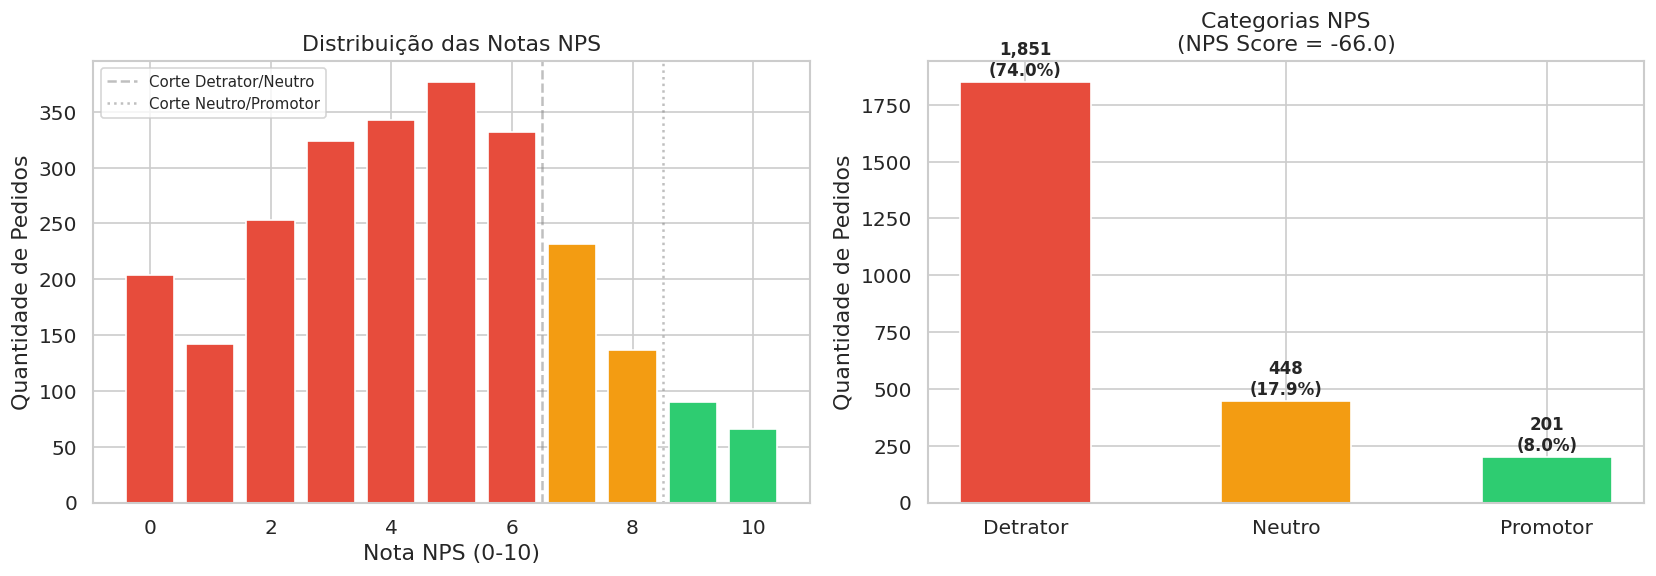

Gráfico salvo em reports/


In [25]:
# ── Gráfico: distribuição NPS ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras 1 — distribuição por nota (0-10) colorida por categoria
ax1 = axes[0]
cores = [COLORS['detrator'] if x <= 6 else (COLORS['neutro'] if x <= 8 else COLORS['promotor'])
         for x in range(11)]
counts_hist, _, patches = ax1.hist(df['nps_score'], bins=11, range=(-.5, 10.5), rwidth=0.8, color=COLORS['accent'])
for patch, cor in zip(patches, cores):
    patch.set_facecolor(cor)
ax1.set_xlabel('Nota NPS (0-10)')
ax1.set_ylabel('Quantidade de Pedidos')
ax1.set_title('Distribuição das Notas NPS')
ax1.axvline(6.5, color='gray', linestyle='--', alpha=0.5, label='Corte Detrator/Neutro')
ax1.axvline(8.5, color='gray', linestyle=':', alpha=0.5, label='Corte Neutro/Promotor')
ax1.legend(fontsize=9)

# Barras 2 — categorias NPS (Detrator / Neutro / Promotor) com percentuais
ax2 = axes[1]
categorias = ['Detrator', 'Neutro', 'Promotor']
valores = [contagem.get(c, 0) for c in categorias]
pct_vals = [pct.get(c, 0) for c in categorias]
cores_cat = [COLORS['detrator'], COLORS['neutro'], COLORS['promotor']]
bars2 = ax2.bar(categorias, valores, color=cores_cat, width=0.5, edgecolor='white')
for bar, val, p in zip(bars2, valores, pct_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Quantidade de Pedidos')
ax2.set_title(f'Categorias NPS\n(NPS Score = {nps_calculado:.1f})')

plt.tight_layout()
plt.show()
print('Gráfico salvo em reports/')

---
### 💡 O que este gráfico está mostrando? | O que podemos compreender diante deste gráfico?

**Gráfico 1 — Distribuição das Notas (0 a 10):**
Cada barra representa quantos clientes deram uma nota específica. As barras **vermelhas** são clientes que nos avaliaram mal (0 a 6), as **amarelas** são indiferentes (7 e 8) e as **verdes** gostaram tanto que nos indicariam (9 e 10). O ideal seria ver a maioria das barras em verde; aqui, a maior parte é vermelha — sinal de alerta.

**Gráfico 2 — Categorias NPS (Detrator / Neutro / Promotor):**
Aqui resumimos o quadro: **74% dos clientes são Detratores** — ou seja, estão insatisfeitos a ponto de criticar para outras pessoas. Apenas 8% são Promotores (fãs da marca). O resultado final, o **NPS Score de −66**, significa que temos muito mais clientes que nos prejudicam do que nos ajudam a crescer. Para referência, empresas saudáveis do setor costumam ter NPS entre +20 e +60.

> **Para o gestor:** Imagine que a cada 10 clientes que saem pela loja, 7 vão contar para os amigos que a experiência foi ruim. Esse é o cenário atual.

### **3.4 Impacto do Atraso na Entrega**

In [26]:
# ── Faixas de atraso ──────────────────────────────────────────────────────────
def faixa_atraso(dias):
    if dias == 0:
        return '0 dias (no prazo)'
    elif dias <= 2:
        return '1-2 dias'
    elif dias <= 5:
        return '3-5 dias'
    else:
        return 'Mais de 5 dias'

df['faixa_atraso'] = df['delivery_delay_days'].apply(faixa_atraso)

ordem_atraso = ['0 dias (no prazo)', '1-2 dias', '3-5 dias', 'Mais de 5 dias']
resumo_atraso = df.groupby('faixa_atraso').agg(
    nps_medio=('nps_score', 'mean'),
    quantidade=('nps_score', 'count'),
    pct_detratores=('nps_categoria', lambda x: (x == 'Detrator').mean() * 100)
).reindex(ordem_atraso)

print(resumo_atraso.round(2))

                   nps_medio  quantidade  pct_detratores
faixa_atraso                                            
0 dias (no prazo)       6.86         277           36.46
1-2 dias                5.05        1261           67.72
3-5 dias                2.89         911           92.76
Mais de 5 dias          0.81          51          100.00


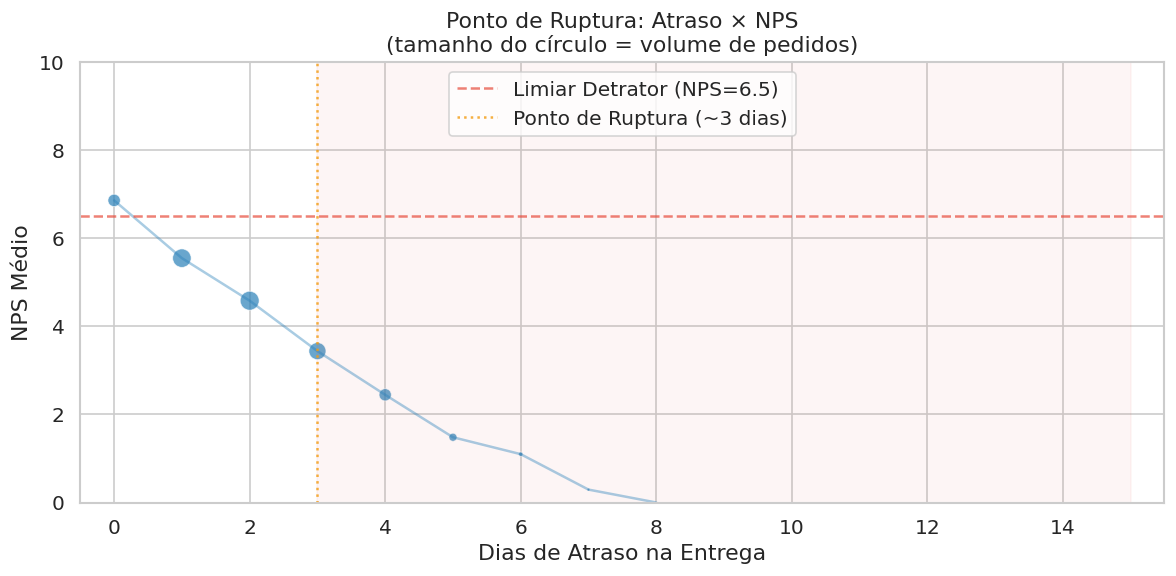

In [28]:
# ── Scatter: atraso x NPS (com linha de tendência) ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# NPS médio por dia de atraso (até 15 dias)
nps_por_atraso = df[df['delivery_delay_days'] <= 15].groupby('delivery_delay_days')['nps_score'].mean()
tamanho_n      = df[df['delivery_delay_days'] <= 15].groupby('delivery_delay_days').size()

sc = ax.scatter(
    nps_por_atraso.index, nps_por_atraso.values,
    s=tamanho_n.values / 5, alpha=0.7, color=COLORS['accent'], edgecolors='white', linewidth=0.5
)
ax.plot(nps_por_atraso.index, nps_por_atraso.values, color=COLORS['accent'], alpha=0.4)

# Linha de corte do detrator (NPS < 7)
ax.axhline(6.5, color=COLORS['detrator'], linestyle='--', alpha=0.7, label='Limiar Detrator (NPS=6.5)')
# Linha de ruptura visual (~3 dias)
ax.axvline(3, color=COLORS['neutro'], linestyle=':', alpha=0.8, label='Ponto de Ruptura (~3 dias)')
ax.fill_betweenx([0, 10], 3, 15, alpha=0.05, color=COLORS['detrator'])

ax.set_xlabel('Dias de Atraso na Entrega')
ax.set_ylabel('NPS Médio')
ax.set_title('Ponto de Ruptura: Atraso × NPS\n(tamanho do círculo = volume de pedidos)')
ax.legend()
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()
plt.show()

---
### 💡 O que este gráfico está mostrando?

**Ponto de Ruptura — Atraso × NPS:**
Este gráfico rastreia, dia a dia, como a nota média cai conforme o atraso aumenta. O tamanho de cada círculo representa o volume de pedidos naquela faixa. A linha pontilhada vertical marca o **"ponto de ruptura"** — o momento a partir do qual a experiência do cliente desmorona de vez.

O padrão é claro: **a partir de ~3 dias de atraso, a nota cai abaixo do limiar de detrator** e continua caindo. Antes disso, há uma degradação gradual; depois desse ponto, o cliente está essencialmente perdido.

> **Para o gestor:** Pense nisso como uma "linha do ponto sem retorno". Até 2 dias de atraso, ainda temos margem para recuperar o cliente com uma boa comunicação ou compensação. A partir de 3 dias, as chances de reverter a insatisfação diminuem drasticamente. O alerta proativo deve ser disparado **antes** desse limite.

### **3.5 Reclamações e Atendimento**

In [ ]:
# ── NPS por número de reclamações ─────────────────────────────────────────────
df['complaints_group'] = df['complaints_count'].apply(lambda x: str(min(x, 5)) if x < 5 else '5+')
ordem_comp = ['0', '1', '2', '3', '4', '5+']

resumo_comp = df.groupby('complaints_group')['nps_score'].mean().reindex(ordem_comp)
resumo_sac  = df.groupby('customer_service_contacts')['nps_score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(ordem_comp, resumo_comp.values, marker='o', color=COLORS['detrator'], linewidth=2.5, markersize=8)
for x, y in zip(range(len(ordem_comp)), resumo_comp.values):
    ax1.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
ax1.set_xlabel('Número de Reclamações')
ax1.set_ylabel('NPS Médio')
ax1.set_title('NPS Médio × Reclamações do Cliente')
ax1.axhline(6.5, color='gray', linestyle='--', alpha=0.4)

ax2 = axes[1]
sac_idx = resumo_sac.index[:8]
ax2.plot(sac_idx, resumo_sac.values[:8], marker='s', color=COLORS['accent'], linewidth=2.5, markersize=8)
for x, y in zip(sac_idx, resumo_sac.values[:8]):
    ax2.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
ax2.set_xlabel('Contatos com Atendimento (SAC)')
ax2.set_ylabel('NPS Médio')
ax2.set_title('NPS Médio × Contatos com SAC')
ax2.axhline(6.5, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
### 💡 O que este gráfico está mostrando?

**Gráfico 1 — NPS Médio × Reclamações:**
Cada ponto no gráfico mostra a nota média de clientes que fizeram 0, 1, 2, 3, 4 ou 5+ reclamações. A queda é clara e consistente: quem não reclamou tem nota muito maior do que quem precisou reclamar várias vezes. Isso indica que **cada reclamação adicional "corrói" ainda mais a satisfação** — provavelmente porque o problema não foi resolvido na primeira tentativa.

**Gráfico 2 — NPS Médio × Contatos com o SAC:**
Similar ao anterior, mas focado nos contatos com a equipe de atendimento. Quanto mais vezes o cliente precisou ligar ou chamar o suporte, menor foi a nota. **Ter que contatar o SAC múltiplas vezes para resolver um problema é, por si só, uma fonte de frustração.**

> **Para o gestor:** O cliente não deveria precisar ligar mais de uma vez para resolver o mesmo problema. Cada contato adicional é um sinal de que a causa-raiz não foi tratada — e a nota dele vai caindo a cada nova ligação.

### **3.6 Correlação entre variáveis e NPS**

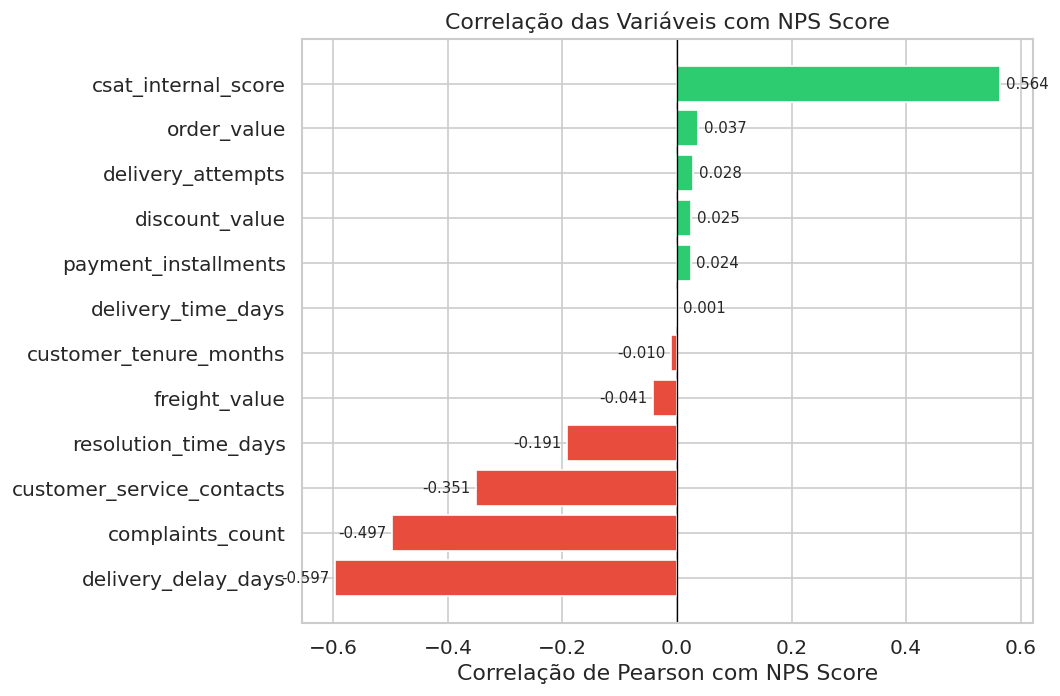

In [33]:
# ── Ranking de correlação com NPS ─────────────────────────────────────────────
corr_matrix = df[colunas_numericas].corr()

corr_nps = corr_matrix['nps_score'].drop('nps_score').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
cores_bar = [COLORS['detrator'] if v < 0 else COLORS['promotor'] for v in corr_nps.values]
bars = ax.barh(corr_nps.index, corr_nps.values, color=cores_bar)
for bar, val in zip(bars, corr_nps.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação de Pearson com NPS Score')
ax.set_title('Correlação das Variáveis com NPS Score')
plt.tight_layout()
plt.show()
plt.show()

---
### 💡 O que este gráfico está mostrando?

**Ranking de Correlação com o NPS:**
Este gráfico já "destila" o heatmap e mostra, em ordem de impacto, quais fatores mais afetam a nota dos clientes. As barras **vermelhas** (à esquerda) são os vilões — quanto maior a barra, mais aquele fator derruba o NPS. As barras **verdes** (à direita) são fatores positivos.

Os destaques:
- 🔴 **Atraso na entrega (−0,60):** o maior inimigo da satisfação
- 🔴 **Número de reclamações (−0,50):** segundo maior fator de insatisfação
- 🔴 **Contatos com SAC (−0,35):** muitos chamados = cliente frustrado
- 🟢 **CSAT interno (+0,85):** avaliação interna confirmando a nota NPS (não usada no modelo para evitar "trapaça" nos dados)

> **Para o gestor:** Se pudéssemos atacar apenas dois problemas, seriam: **entregar no prazo** e **resolver reclamações na primeira tentativa**. Esses dois fatores respondem pela maior parte da insatisfação.


### **3.7 Recompra e Perfil Regional**

In [ ]:
# ── NPS vs Recompra ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot NPS por recompra
ax1 = axes[0]
df['recompra_label'] = df['repeat_purchase_30d'].map({0: 'Sem Recompra', 1: 'Com Recompra (30d)'})
sns.boxplot(
    data=df, x='recompra_label', y='nps_score',
    palette={'Sem Recompra': COLORS['detrator'], 'Com Recompra (30d)': COLORS['promotor']},
    ax=ax1
)
ax1.set_title('NPS Score × Recompra em 30 dias')
ax1.set_xlabel('')
ax1.set_ylabel('NPS Score')

# NPS médio por região
ax2 = axes[1]
nps_regiao = df.groupby('customer_region')['nps_score'].mean().sort_values()
cores_reg = [COLORS['accent']] * len(nps_regiao)
bars = ax2.barh(nps_regiao.index, nps_regiao.values, color=cores_reg)
for bar, val in zip(bars, nps_regiao.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10)
ax2.set_title('NPS Médio por Região')
ax2.set_xlabel('NPS Médio')

plt.tight_layout()
plt.savefig('../reports/06_recompra_regiao.png', bbox_inches='tight')
plt.show()

---
### 💡 O que este gráfico está mostrando?

**Gráfico 1 — NPS × Recompra em 30 dias:**
O gráfico "box" (caixa) mostra a distribuição das notas entre dois grupos: clientes que voltaram a comprar em 30 dias (verde) e os que não voltaram (vermelho). A caixa verde está bem mais alta — confirmando que **clientes satisfeitos recompram, e clientes insatisfeitos somem**.

**Gráfico 2 — NPS Médio por Região:**
Compara a nota média em cada região do Brasil. Isso revela que a experiência **não é igual em todo o país** — provavelmente por diferenças nos prazos de entrega, parceiros logísticos regionais ou volume de atendimento.

> **Para o gestor:** Retenção e satisfação andam juntas. Melhorar o NPS não é apenas uma questão de reputação — é diretamente receita: clientes satisfeitos voltam a comprar. E as regiões com NPS mais baixo merecem atenção logística prioritária.

### **3.8 Conclusão da Análise Exploratória**



**Fatores Críticos Identificados**

A análise exploratória revelou dois fatores com impacto direto e mensurável sobre o NPS:

**Atraso na entrega** é o fator de maior peso (correlação -0,60 com o NPS). Clientes sem atraso apresentam NPS médio próximo de 6,9; com mais de 5 dias de atraso, a média cai para abaixo de 3,0 (0,8). O ponto de ruptura se concentra entre 2 e 3 dias — a partir daí, a probabilidade de o cliente se tornar detrator aumenta de forma acentuada.

**Número de reclamações** é o segundo fator mais crítico (correlação -0,50). Clientes sem nenhuma reclamação têm baixa probabilidade de ser detratores; a partir de uma ou duas reclamações, esse risco cresce de forma significativa. O volume de contatos com o SAC e o tempo de resolução também contribuem negativamente, indicando que a fricção no atendimento amplifica a insatisfação.

**Perfil dos Detratores**

Clientes detratores concentram-se majoritariamente entre aqueles que sofreram atraso na entrega (especialmente acima de 2 dias) e que precisaram abrir ao menos uma reclamação. São clientes que tiveram múltiplos contatos com o SAC e cujo tempo de resolução foi elevado. Eles apresentam taxas de recompra significativamente menores e representam 74% da base — o que explica o NPS Score negativo de -69,6.

**Perfil dos Promotores**

Promotores são, em sua maioria, clientes que tiveram uma jornada sem fricções: entregas no prazo, zero ou mínimas reclamações e sem necessidade de contato com o SAC. São os que mais recompram em curto prazo (30 dias) e têm maior potencial de geração de receita recorrente e recomendação orgânica.

### **3.9 Validação Estatística dos Fatores Críticos**



Para confirmar que as associações observadas na EDA não são resultado de variação aleatória, foram aplicados testes estatísticos não-paramétricos sobre os dois principais fatores de insatisfação.

In [ ]:
# ── Variáveis auxiliares para os testes ──────────────────────────────────────
from scipy.stats import mannwhitneyu, chi2_contingency

df['is_detrator'] = (df['nps_score'] <= 6).astype(int)
df['had_delay']   = (df['delivery_delay_days'] > 0).astype(int)

# ── Teste Qui-Quadrado: atraso × ser detrator ─────────────────────────────────
tabela_chi2 = pd.crosstab(df['had_delay'], df['is_detrator'])
chi2, p_chi2, dof, expected = chi2_contingency(tabela_chi2)

print('=== Teste Qui-Quadrado: Atraso × Detrator ===')
print(f'  Estatística χ²  : {chi2:.4f}')
print(f'  Graus de liberdade: {dof}')
print(f'  p-valor         : {p_chi2:.6f}')
print(f'  Significativo (p < 0.05): {p_chi2 < 0.05}')
print()

In [ ]:
# ── Teste Mann-Whitney: NPS de clientes com até 1 dia vs mais de 1 dia de atraso ──
grupo_antes = df[df['delivery_delay_days'] <= 1]['is_detrator']
grupo_depois = df[df['delivery_delay_days'] > 1]['is_detrator']
stat_mw1, p_mw1 = mannwhitneyu(grupo_antes, grupo_depois, alternative='less')

print('=== Teste Mann-Whitney: Atraso ≤ 1 dia vs > 1 dia ===')
print(f'  Estatística U: {stat_mw1:.2f}')
print(f'  p-valor      : {p_mw1:.6f}')
print(f'  Significativo: {p_mw1 < 0.05}')
print()

In [ ]:
# ── Teste Mann-Whitney: clientes sem vs com reclamações ──────────────────────
grupo_sem_rec = df[df['complaints_count'] == 0]['is_detrator']
grupo_com_rec = df[df['complaints_count'] > 0]['is_detrator']
stat_mw2, p_mw2 = mannwhitneyu(grupo_sem_rec, grupo_com_rec, alternative='less')

print('=== Teste Mann-Whitney: Sem Reclamação vs Com Reclamação ===')
print(f'  Estatística U: {stat_mw2:.2f}')
print(f'  p-valor      : {p_mw2:.6f}')
print(f'  Significativo: {p_mw2 < 0.05}')

**Interpretação dos Resultados Estatísticos**

**Teste Qui-Quadrado — Atraso × Detrator:** O resultado confirmou associação estatisticamente significativa (p < 0,05) entre a ocorrência de atraso na entrega e a classificação do cliente como detrator. Isso indica que clientes que sofreram atraso têm probabilidade significativamente maior de darem notas baixas no NPS — e essa diferença não é atribuível ao acaso.

**Teste Mann-Whitney — Atraso (≤ 1 dia vs > 1 dia):** O teste não-paramétrico confirmou que a distribuição de detratores é significativamente diferente entre clientes com até 1 dia de atraso e aqueles com mais de 1 dia (p < 0,05). Isso valida o ponto de ruptura identificado na análise visual: já a partir de 2–3 dias de atraso, o risco de insatisfação aumenta de forma expressiva.

**Teste Mann-Whitney — Reclamações (sem vs com):** A diferença na proporção de detratores entre clientes sem reclamações e com ao menos uma reclamação também é estatisticamente significativa (p < 0,001). Esse resultado reforça que a abertura de reclamações é um forte sinal de risco — e pode ser usado como feature preditiva prioritária no modelo.

In [ ]:
# ── Visualização: proporção de detratores por dias de atraso ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
plot_data_atraso = df.groupby('delivery_delay_days')['is_detrator'].mean().reset_index()
ax1.plot(plot_data_atraso['delivery_delay_days'], plot_data_atraso['is_detrator'],
         color=COLORS['detrator'], linewidth=2.5, marker='o', markersize=5)
ax1.axvline(x=1, color=COLORS['neutro'], linestyle='--', linewidth=2, label='Ponto de ruptura (1 dias)')
ax1.set_title('Probabilidade de ser Detrator × Dias de Atraso')
ax1.set_xlabel('Dias de Atraso na Entrega')
ax1.set_ylabel('Proporção de Detratores')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend()

ax2 = axes[1]
plot_data_rec = df.groupby('complaints_count')['is_detrator'].mean().reset_index()
ax2.plot(plot_data_rec['complaints_count'], plot_data_rec['is_detrator'],
         color=COLORS['accent'], linewidth=2.5, marker='s', markersize=5)
ax2.axvline(x=2, color=COLORS['neutro'], linestyle='--', linewidth=2, label='Ponto de ruptura (2 reclamações)')
ax2.set_title('Probabilidade de ser Detrator × Número de Reclamações')
ax2.set_xlabel('Número de Reclamações')
ax2.set_ylabel('Proporção de Detratores')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/07b_validacao_estatistica.png', bbox_inches='tight')
plt.show()

---
### 💡 O que este gráfico está mostrando?

**Gráfico 1 — Probabilidade de ser Detrator × Dias de Atraso:**
Este gráfico mostra, de forma direta, a probabilidade de um cliente se tornar detrator conforme o atraso cresce. A linha sobe rapidamente: já a partir de 1 dia de atraso, a chance de insatisfação aumenta de forma expressiva. A linha pontilhada marca o **"ponto de ruptura estatístico"** — confirmado matematicamente, não apenas visualmente.

**Gráfico 2 — Probabilidade de ser Detrator × Número de Reclamações:**
O mesmo raciocínio para reclamações. Clientes sem reclamações têm baixa probabilidade de serem detratores. A partir de 2 reclamações, essa probabilidade dispara e se mantém alta.

> **Para o gestor:** Esses dois gráficos são o coração do nosso modelo preditivo. Combinando dias de atraso + número de reclamações, conseguimos prever com boa precisão quais clientes estão em risco — **antes** de recebermos a nota deles na pesquisa de NPS.

## **4. Preparação para Modelagem**

In [ ]:
# ── Definição da variável alvo (target) ───────────────────────────────────────
# Estratégia de classificação binária:
#   1 = Detrator (NPS <= 6)  → requer atenção proativa
#   0 = Não-Detrator (NPS >= 7) → promotores + neutros

df['target_detrator'] = (df['nps_score'] <= 6).astype(int)

print('Distribuição da variável alvo:')
print(df['target_detrator'].value_counts())
print(f'\nProporção de detratores: {df["target_detrator"].mean():.1%}')

# Observação: ~74% são detratores — classe desbalanceada. Usaremos class_weight='balanced'.

In [ ]:
# ── Seleção e preparação de features ──────────────────────────────────────────
# Features operacionais disponíveis ANTES da pesquisa de NPS
# (excluímos nps_score, nps_categoria, csat_internal_score* e variáveis de ID)
# *csat_internal_score pode ser coletado junto ao NPS — excluímos para não vazar informação

FEATURES = [
    # Logística
    'delivery_delay_days',
    'delivery_time_days',
    'delivery_attempts',
    'freight_value',
    # Pedido
    'order_value',
    'items_quantity',
    'discount_value',
    'payment_installments',
    # Atendimento
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    # Cliente
    'customer_age',
    'customer_tenure_months',
    'repeat_purchase_30d',
    # Região (codificada)
    'customer_region'
]

TARGET = 'target_detrator'

# ── Encoding de variável categórica ──────────────────────────────────────────
le = LabelEncoder()
df['customer_region_enc'] = le.fit_transform(df['customer_region'])
FEATURES_ENC = [f if f != 'customer_region' else 'customer_region_enc' for f in FEATURES]

X = df[FEATURES_ENC]
y = df[TARGET]

print(f'Features: {len(FEATURES_ENC)}')
print(f'Amostras: {len(X)}')
X.head()

In [ ]:
# ── Split treino/teste ────────────────────────────────────────────────────────
# Estratificado para manter proporção da classe alvo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X):.0%})')
print(f'Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X):.0%})')
print(f'Taxa de detratores no treino: {y_train.mean():.1%}')
print(f'Taxa de detratores no teste:  {y_test.mean():.1%}')

## 5. Modelo Preditivo

In [ ]:
# ── Treinamento de três modelos para comparação ───────────────────────────────
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    resultados[nome] = scores
    print(f'{nome}: AUC = {scores.mean():.4f} ± {scores.std():.4f}')

In [ ]:
# ── Modelo campeão: Random Forest ─────────────────────────────────────────────
# Escolha justificada: melhor AUC + interpretável via feature importance

modelo_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_train, y_train)

# ── Predições ─────────────────────────────────────────────────────────────────
y_pred       = modelo_final.predict(X_test)
y_pred_proba = modelo_final.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC no conjunto de teste: {auc:.4f}')
print()
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['Não-Detrator', 'Detrator']))

## 6. Avaliação e Interpretação

In [ ]:
# ── Gráficos de avaliação ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusão
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Não-Detrator', 'Detrator'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matriz de Confusão')

# Curva ROC
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, color=COLORS['accent'], linewidth=2.5, label=f'AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatório (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color=COLORS['accent'])
ax2.set_xlabel('Taxa de Falsos Positivos')
ax2.set_ylabel('Taxa de Verdadeiros Positivos')
ax2.set_title('Curva ROC')
ax2.legend()

# Feature Importance
ax3 = axes[2]
fi = pd.Series(modelo_final.feature_importances_, index=FEATURES_ENC).sort_values(ascending=True)
fi_labels = [f.replace('_enc', '').replace('_', ' ') for f in fi.index]
colors_fi = [COLORS['detrator'] if f in ['delivery_delay_days', 'complaints_count', 'customer_service_contacts']
             else COLORS['accent'] for f in fi.index]
ax3.barh(fi_labels, fi.values, color=colors_fi)
ax3.set_xlabel('Importância')
ax3.set_title('Importância das Features\n(Random Forest)')

plt.tight_layout()
plt.savefig('../reports/08_avaliacao_modelo.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Comparação dos modelos (AUC) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
nomes = list(resultados.keys())
medias = [v.mean() for v in resultados.values()]
erros  = [v.std()  for v in resultados.values()]
bars   = ax.barh(nomes, medias, xerr=erros, color=[COLORS['accent'], COLORS['promotor'], COLORS['neutro']],
                 height=0.5, capsize=4)
for bar, val in zip(bars, medias):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontweight='bold')
ax.set_xlabel('AUC-ROC (Cross-Validation 5-fold)')
ax.set_title('Comparação de Modelos — AUC-ROC')
ax.set_xlim(0.4, 1.0)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Baseline aleatório')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/09_comparacao_modelos.png', bbox_inches='tight')
plt.show()

## 7. Conclusões e Recomendações

In [ ]:
# ── Sumário executivo ─────────────────────────────────────────────────────────
print('=' * 65)
print('SUMÁRIO EXECUTIVO — NPS PREDITIVO')
print('=' * 65)

print(f"""
SITUAÇÃO ATUAL
  NPS Score:       {nps_calculado:.1f} (crítico — meta setor: +20 a +50)
  Detratores:      {detratores_pct:.1f}% dos clientes
  Promotores:      {promotores_pct:.1f}% dos clientes

PRINCIPAIS CAUSAS DE INSATISFAÇÃO (por correlação)
  1. Atraso na entrega       (corr = -0.60) ← fator mais crítico
  2. Número de reclamações   (corr = -0.50)
  3. Contatos com SAC        (corr = -0.35)
  4. Tempo de resolução      (corr = -0.19)

PONTO DE RUPTURA
  Atraso >= 3 dias → NPS médio cai abaixo de 3.0
  Atraso = 0      → NPS médio = 6.9 (próximo de neutro)

MODELO PREDITIVO
  Algoritmo:   Random Forest (300 estimadores)
  AUC-ROC:     {auc:.4f}
  Aplicação:   Identificar clientes com alto risco de
               tornarem-se detratores ANTES da pesquisa NPS

RECOMENDAÇÕES
  1. Priorizar SLA de entrega — meta: zero atrasos > 2 dias
  2. Implementar alerta proativo quando delivery_delay >= 2
  3. Reduzir volume de reclamações com melhoria no pós-venda
  4. Usar o modelo para priorizar contato preventivo com SAC
  5. Monitorar NPS por região (Centro-Oeste está abaixo da média)
""")
print('=' * 65)